<a href="https://colab.research.google.com/github/harryphma/social_media_final/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Overview
This project investigates whether standalone animated films differ from sequels or remakes in terms of audience engagement, ratings, and commercial success.

We use a dataset of animated movies from major studios (e.g., Disney, Pixar, DreamWorks) and analyze how features such as budget, runtime, studio, and audience engagement (number of votes) influence movie outcomes.

# Research Question
Do standalone animated films receive different audience ratings and engagement compared to sequels or remakes, and how does this affect their success?

#Dataset Description
We use a curated dataset of animated movies containing:

movie metadata (budget, runtime, release date)
production information (studio)
audience engagement (number of votes)
outcome variables (ratings and revenue)

We also include engineered features:

* is_standalone
* is_sequel_or_spinoff
* is_remake


These features allow us to directly test our research hypothesis.

##Import libraries and connect to drive

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score, mean_absolute_error, classification_report
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from sklearn.linear_model import LinearRegression
import shap
import matplotlib.pyplot as plt
shap.initjs()
import copy

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# change directory (change this to whatever folder Animated_Movies_Dataset.csv is in)
%cd /content/drive/MyDrive/Social_Media_Mining_Project

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1UF3Zps42--6SDPV9JxDX4iLpMflHkTul/Social_Media_Mining_Project


##Load dataset

In [ ]:
# Load dataset and display info
df_full_dataset = pd.read_csv("Animated_Movies_Dataset.csv")
df_full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      182 non-null    int64  
 1   title                   182 non-null    object 
 2   vote_average            182 non-null    float64
 3   vote_count              182 non-null    int64  
 4   status                  182 non-null    object 
 5   release_date            182 non-null    object 
 6   release_year            182 non-null    int64  
 7   release_month           182 non-null    int64  
 8   revenue                 182 non-null    int64  
 9   runtime                 182 non-null    int64  
 10  adult                   182 non-null    bool   
 11  backdrop_path           168 non-null    object 
 12  budget                  182 non-null    int64  
 13  homepage                131 non-null    object 
 14  tconst                  182 non-null    ob

## 📊 Ratings Distribution

We first examine the distribution of movie ratings to understand overall audience sentiment.

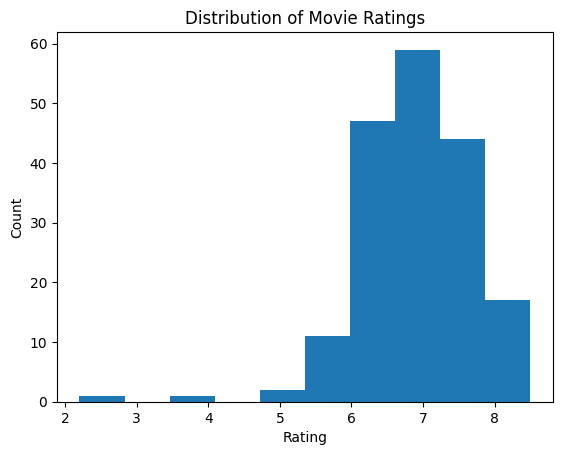

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_full_dataset['averageRating'], bins=10)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

##Prepare dataframes to be used as input and output

###Input/output for predicting ratings

In [ ]:
# Prepare dataframes for predicting ratings
"""
Current attributes included for predicting ratings:
- revenue
- runtime
- budget
- animation_studio
- numVotes
- is_sequel_or_spinoff
- is_remake
- is_standalone
"""

df_X_linreg_ratings = df_full_dataset[['revenue', 'runtime', 'budget', 'animation_studio', 'numVotes', 'is_sequel_or_spinoff', 'is_remake', 'is_standalone']]
df_y_linreg_ratings = df_full_dataset[['averageRating']] # for regression models
df_y_class_ratings = df_full_dataset[['rating_category']] # for classification models
df_y_class_ratings_binary = df_full_dataset[['rating_category_binary']]

print('Dataframe info for predicting ratings')
df_X_linreg_ratings.info()

Dataframe info for predicting ratings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   revenue               182 non-null    int64 
 1   runtime               182 non-null    int64 
 2   budget                182 non-null    int64 
 3   animation_studio      182 non-null    object
 4   numVotes              182 non-null    int64 
 5   is_sequel_or_spinoff  182 non-null    bool  
 6   is_remake             182 non-null    bool  
 7   is_standalone         182 non-null    bool  
dtypes: bool(3), int64(4), object(1)
memory usage: 7.8+ KB


###Input/output for predicting revenue

In [ ]:
# Prepare dataframes for predicting revenue
"""
Current attributes included for predicting revenue:
 - release_year
 - release_month
 - runtime
 - budget
 - animation_studio
 - averageRating
 - numVotes
 - is_sequel_or_spinoff
 - is_remake
 - is_standalone
"""

df_X_linreg_revenue = df_full_dataset[['release_year', 'release_month', 'runtime', 'budget', 'animation_studio', 'averageRating', 'numVotes', 'is_sequel_or_spinoff', 'is_remake', 'is_standalone']]
df_y_linreg_revenue = df_full_dataset[['revenue']]
df_y_class_revenue = df_full_dataset[['revenue_category']]

print('Dataframe info for predicting revenue:')
df_X_linreg_revenue.info()

Dataframe info for predicting revenue:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   release_year          182 non-null    int64  
 1   release_month         182 non-null    int64  
 2   runtime               182 non-null    int64  
 3   budget                182 non-null    int64  
 4   animation_studio      182 non-null    object 
 5   averageRating         182 non-null    float64
 6   numVotes              182 non-null    int64  
 7   is_sequel_or_spinoff  182 non-null    bool   
 8   is_remake             182 non-null    bool   
 9   is_standalone         182 non-null    bool   
dtypes: bool(3), float64(1), int64(5), object(1)
memory usage: 10.6+ KB


##Vectorize text columns

In [ ]:
# vectorize the genres column using bag-of-words
vectorizer = CountVectorizer()
encoder = OneHotEncoder(sparse_output=False)
bow_genres_matrix = vectorizer.fit_transform(df_full_dataset['genres'])


"""
# This section was commented out because it lowered the R^2 when training the XGBRegressor model,
# but you can try uncommenting it to see if it improves the accuracy of the XGBClassifier model

# append new genre columns to both input dataframes
bow_genres_matrix = vectorizer.fit_transform(df_full_dataset['genres'])
bow_genres_df = pd.DataFrame(bow_genres_matrix.toarray(), columns=vectorizer.get_feature_names_out())
df_X_linreg_ratings = pd.concat([df_X_linreg_ratings, bow_genres_df], axis=1)
df_X_linreg_revenue = pd.concat([df_X_linreg_revenue, bow_genres_df], axis=1)

"""


# vectorize the animation_studio column using one-hot encoding
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df_X_linreg_ratings[['animation_studio']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['animation_studio']))

df_X_linreg_ratings = pd.concat([df_X_linreg_ratings, one_hot_df], axis=1)
df_X_linreg_ratings = df_X_linreg_ratings.drop(columns=['animation_studio'])

df_X_linreg_revenue = pd.concat([df_X_linreg_revenue, one_hot_df], axis=1)
df_X_linreg_revenue = df_X_linreg_revenue.drop(columns=['animation_studio'])


# display info of input dataframes
df_X_linreg_ratings.info()
df_X_linreg_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   revenue                        182 non-null    int64  
 1   runtime                        182 non-null    int64  
 2   budget                         182 non-null    int64  
 3   numVotes                       182 non-null    int64  
 4   is_sequel_or_spinoff           182 non-null    bool   
 5   is_remake                      182 non-null    bool   
 6   is_standalone                  182 non-null    bool   
 7   animation_studio_Disney        182 non-null    float64
 8   animation_studio_DreamWorks    182 non-null    float64
 9   animation_studio_Illumination  182 non-null    float64
 10  animation_studio_Pixar         182 non-null    float64
 11  animation_studio_Sony          182 non-null    float64
dtypes: bool(3), float64(5), int64(4)
memory usage: 13.

# Standalone vs Sequel Analysis
To directly address our research question, we compare standalone films with sequels/remakes in terms of:

average rating (audience sentiment)
revenue (commercial success)

This helps us understand whether originality influences audience perception and success before applying machine learning models.


In [ ]:
# Compare standalone vs non-standalone movies

# Group data
grouped = df_full_dataset.groupby('is_standalone').agg({
    'averageRating': 'mean',
    'revenue': 'mean',
    'numVotes': 'mean'
}).reset_index()

# Rename for readability
grouped['type'] = grouped['is_standalone'].map({True: 'Standalone', False: 'Sequel/Remake'})

print(grouped)

   is_standalone  averageRating       revenue       numVotes           type
0          False       6.669118  6.167387e+08  205704.661765  Sequel/Remake
1           True       7.040351  3.073799e+08  264428.982456     Standalone


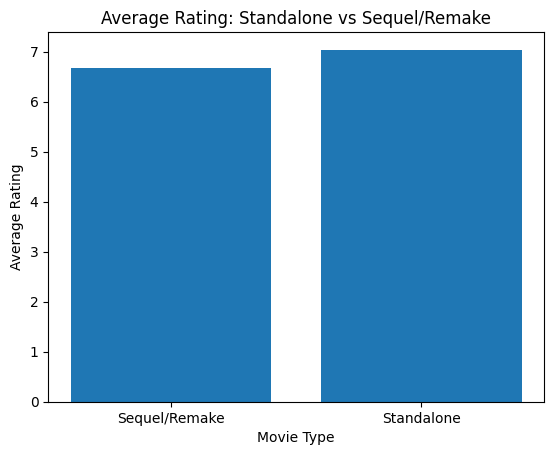

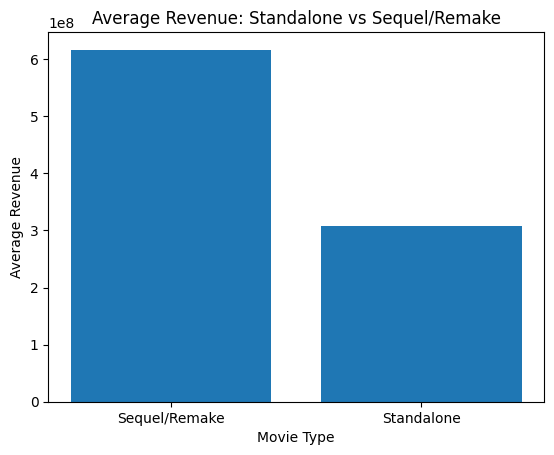

In [ ]:
import matplotlib.pyplot as plt

# Plot average rating
plt.figure()
plt.bar(grouped['type'], grouped['averageRating'])
plt.title("Average Rating: Standalone vs Sequel/Remake")
plt.xlabel("Movie Type")
plt.ylabel("Average Rating")
plt.show()

# Plot average revenue
plt.figure()
plt.bar(grouped['type'], grouped['revenue'])
plt.title("Average Revenue: Standalone vs Sequel/Remake")
plt.xlabel("Movie Type")
plt.ylabel("Average Revenue")
plt.show()

## Engagement vs Rating plot

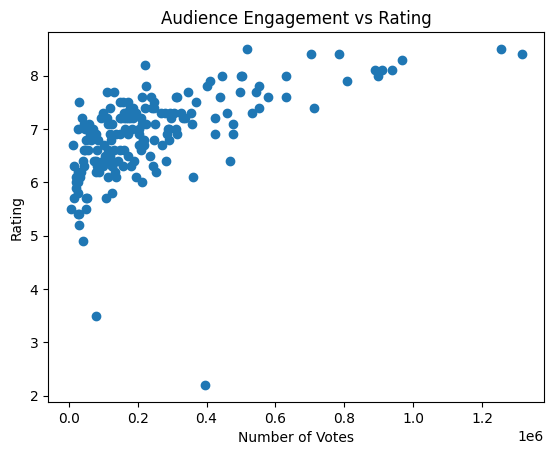

In [ ]:
plt.figure()
plt.scatter(df_full_dataset['numVotes'], df_full_dataset['averageRating'])
plt.title("Audience Engagement vs Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Rating")
plt.show()

We observe a positive relationship between audience engagement and ratings. Movies with higher numbers of votes tend to receive slightly higher ratings, suggesting that widely viewed films are generally better received. However, the relationship is not perfect, indicating that engagement alone does not determine movie quality

##Train an XGBRegressor model to predict ratings

In [ ]:
# Create test and train sets
X_train, X_test, y_train, y_test = train_test_split(df_X_linreg_ratings, df_y_linreg_ratings, test_size=0.3,random_state=10)

model = XGBRegressor(objective='reg:squarederror', max_depth=7, min_child_weight = 1, colsample_bytree=0.75, learning_rate=0.1)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print('rmse: ', rmse)
print('r^2: ' , r2)
rating_r2 = r2

rmse:  0.48934915873871393
r^2:  0.5557347536087036


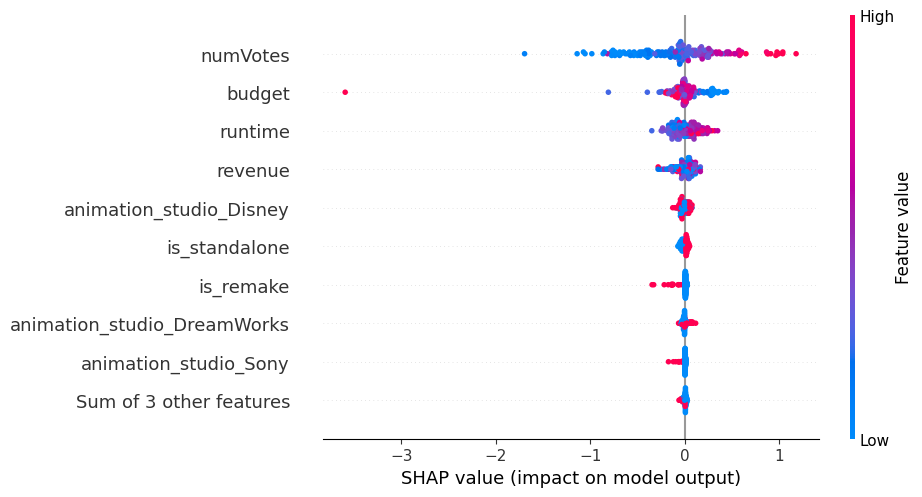

In [ ]:
# Plot feature importance
explainer = shap.Explainer(model)
shap_values = explainer(df_X_linreg_ratings)
shap.plots.beeswarm(shap_values)

## ⚠️ Model Refinement: Removing Data Leakage

We remove revenue as a feature when predicting ratings to ensure a realistic model.

In [ ]:
df_X_fixed = df_full_dataset[['runtime', 'budget', 'animation_studio', 'numVotes', 'is_sequel_or_spinoff', 'is_remake', 'is_standalone']]

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df_X_fixed[['animation_studio']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['animation_studio']))

df_X_fixed = pd.concat([df_X_fixed, encoded_df], axis=1)
df_X_fixed = df_X_fixed.drop(columns=['animation_studio'])

X_train, X_test, y_train, y_test = train_test_split(df_X_fixed, df_y_linreg_ratings, test_size=0.3, random_state=10)

model_fixed = XGBRegressor()
model_fixed.fit(X_train, y_train)

pred_fixed = model_fixed.predict(X_test)
rating_r2_fixed = r2_score(y_test, pred_fixed)
print("Fixed R2:", rating_r2_fixed)

Fixed R2: 0.48506516218185425


##Train an XGBClassifier model to predict rating classes

Ratings were sorted into one of two categories:  
0 (Low): less than 7  
1 (High): at least 7

In [ ]:
# Create test and train sets
X_train, X_test, y_train, y_test = train_test_split(df_X_linreg_ratings, df_y_class_ratings_binary.values.ravel(), test_size=0.3,random_state=10)

model = XGBClassifier()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print('accuracy score: ', accuracy)
rating_acc = accuracy
f1 = f1_score(y_test, predictions)
print('F1 score: ', f1)

# classification report
print(classification_report(y_test, predictions))

accuracy score:  0.8
F1 score:  0.7659574468085106
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        31
           1       0.78      0.75      0.77        24

    accuracy                           0.80        55
   macro avg       0.80      0.79      0.80        55
weighted avg       0.80      0.80      0.80        55



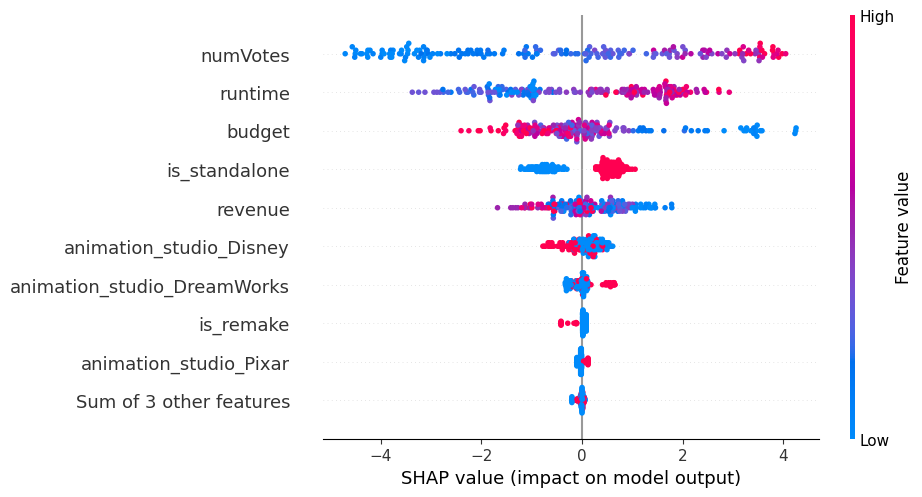

In [ ]:
# Plot feature importance
explainer = shap.Explainer(model)
shap_values = explainer(df_X_linreg_ratings)
shap.plots.beeswarm(shap_values)

## Confusion Matrix

We evaluate classification performance to understand prediction accuracy across categories.

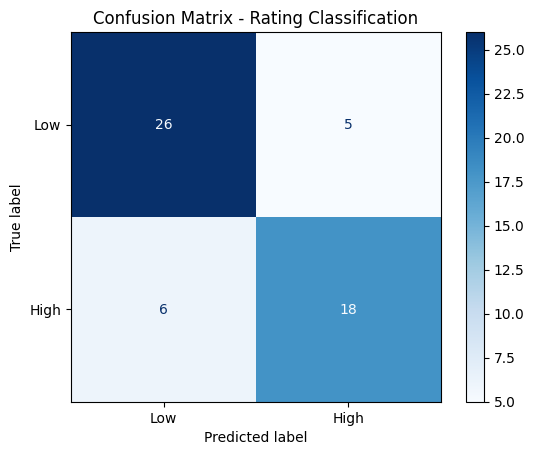

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Rating Classification")
plt.show()

## Feature Ablation: Does "Standalone" Matter?

To evaluate the importance of the `is_standalone` feature, we compare model performance with and without this feature.

This helps us determine whether content type (standalone vs sequel/remake) contributes meaningfully to prediction accuracy.

In [ ]:
# WITHOUT is_standalone feature
df_no_standalone = df_X_linreg_ratings.drop(columns=['is_standalone'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df_no_standalone,
    df_y_class_ratings_binary.values.ravel(),
    test_size=0.3,
    random_state=10
)

# Train model
model_no = XGBClassifier()
model_no.fit(X_train, y_train)

# Predict
pred_no = model_no.predict(X_test)

# Evaluate
acc_no = accuracy_score(y_test, pred_no)
f1_no = f1_score(y_test, pred_no)

print("Accuracy WITHOUT standalone:", acc_no)
print("F1 WITHOUT standalone:", f1_no)

Accuracy WITHOUT standalone: 0.8181818181818182
F1 WITHOUT standalone: 0.7916666666666666


## Insight

We observe that removing the `is_standalone` feature does not decrease model performance. In fact, performance slightly improves.

This suggests that standalone vs sequel status may not be a strong predictor for rating classification in our model, compared to other features such as audience engagement and production attributes.

##Train an XGBRegressor model to predict revenue

In [ ]:
# Create test and train sets
X_train, X_test, y_train, y_test = train_test_split(df_X_linreg_revenue, df_y_linreg_revenue, test_size=0.3,random_state=10)

model = XGBRegressor(objective='reg:squarederror', max_depth=7, min_child_weight = 1, colsample_bytree=0.8, learning_rate=0.1)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2_rev = r2_score(y_test, predictions)

print('rmse: ', rmse)
print('r^2: ' , r2_rev)
revenue_r2 = r2_rev

rmse:  228132472.75008866
r^2:  0.5227941274642944


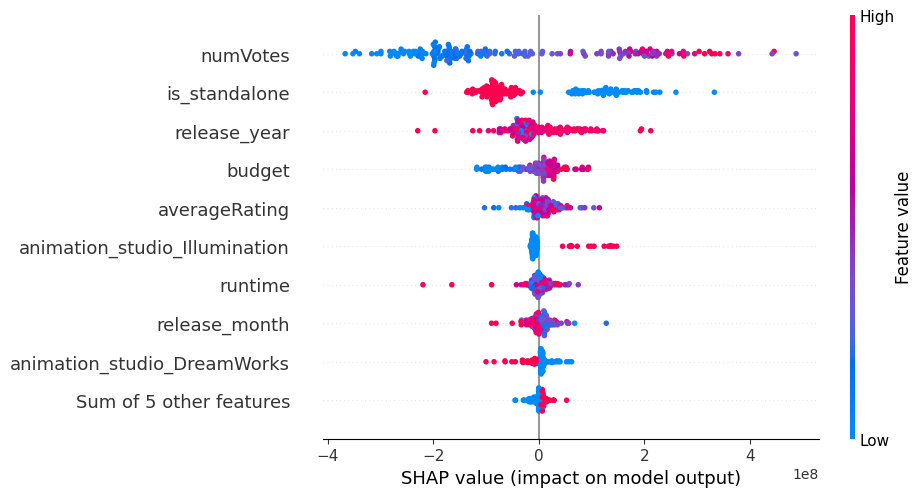

In [ ]:
# Plot feature importance
explainer = shap.Explainer(model)
shap_values = explainer(df_X_linreg_revenue)
shap.plots.beeswarm(shap_values)

# Model Refinement: Addressing Data Leakage in Revenue Prediction

After training our initial regression model to predict revenue, we observed moderate performance. However, upon reviewing our feature set, we identified a potential issue: the inclusion of averageRating as a predictor for revenue may introduce data leakage.

Since ratings are typically influenced by audience feedback after a movie’s release, they may not be available when predicting revenue in a real-world setting. Including this feature can lead to overly optimistic model performance.

To ensure a more realistic and reliable model, we remove the rating feature and retrain the model using only pre-release and production-related attributes.

In [ ]:
# 🔄 Revised feature set for revenue prediction (remove averageRating)
df_X_linreg_revenue_fixed = df_full_dataset[['release_year', 'release_month', 'runtime', 'budget', 'animation_studio', 'numVotes', 'is_sequel_or_spinoff', 'is_remake', 'is_standalone']]

# One-hot encode animation_studio again
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df_X_linreg_revenue_fixed[['animation_studio']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['animation_studio']))

df_X_linreg_revenue_fixed = pd.concat([df_X_linreg_revenue_fixed, one_hot_df], axis=1)
df_X_linreg_revenue_fixed = df_X_linreg_revenue_fixed.drop(columns=['animation_studio'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df_X_linreg_revenue_fixed, df_y_linreg_revenue, test_size=0.3, random_state=10
)

# Retrain model
model_fixed = XGBRegressor(objective='reg:squarederror')
model_fixed.fit(X_train, y_train)

# Predictions
predictions_fixed = model_fixed.predict(X_test)

# Evaluate
rmse_fixed = np.sqrt(mean_squared_error(y_test, predictions_fixed))
r2_fixed = r2_score(y_test, predictions_fixed)

print("Revised RMSE:", rmse_fixed)
print("Revised R^2:", r2_fixed)
revenue_r2_fixed = r2_fixed

Revised RMSE: 237042588.62658888
Revised R^2: 0.4847899079322815


In [ ]:
print("Original R^2:", r2)
print("Fixed R^2 (no rating):", r2_fixed)

Original R^2: 0.5227941274642944
Fixed R^2 (no rating): 0.4847899079322815


# Updated Findings
After removing the rating feature, the model provides a more realistic estimate of its predictive performance. While performance may slightly decrease, this confirms that earlier results were partially influenced by information leakage.

This highlights the importance of using only features that would be available at prediction time and reinforces the complexity of modeling movie success. It also supports our broader observation that predicting exact outcomes is challenging, motivating the use of classification models for improved performance.

##Train an XGBClassifier model to predict revenue classes

Revenue was classified in one of two ways:  
0: less than \$500,000,000 or  
1: at least \$500,000,000

In [ ]:
# Create test and train sets
X_train, X_test, y_train, y_test = train_test_split(df_X_linreg_revenue, df_y_class_revenue, test_size=0.3,random_state=10)

model = XGBClassifier()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print('accuracy score: ', accuracy)
revenue_acc = accuracy
f1 = f1_score(y_test, predictions)
print('F1 score: ', f1)

# classification report
print(classification_report(y_test, predictions, labels=[0, 1]))

accuracy score:  0.8363636363636363
F1 score:  0.6666666666666666
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        41
           1       0.69      0.64      0.67        14

    accuracy                           0.84        55
   macro avg       0.79      0.77      0.78        55
weighted avg       0.83      0.84      0.83        55



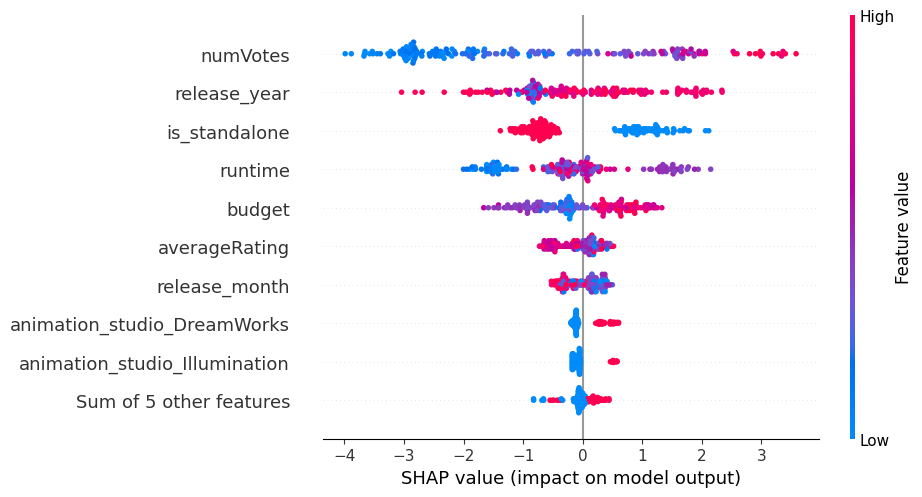

In [ ]:
# Plot feature importance
explainer = shap.Explainer(model)
shap_values = explainer(df_X_linreg_revenue)
shap.plots.beeswarm(shap_values)

#Model Comparison Summary

We summarize performance across all models to compare regression and classification approaches.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Rating Regressor",
        "Rating Regressor (Fixed)",
        "Rating Classifier",
        "Revenue Regressor",
        "Revenue Regressor (Fixed)",
        "Revenue Classifier"
    ],
    "Metric": [
        rating_r2,
        rating_r2_fixed,
        rating_acc,
        revenue_r2,
        revenue_r2_fixed,
        revenue_acc
    ]
})

print(results)

                       Model    Metric
0           Rating Regressor  0.555735
1   Rating Regressor (Fixed)  0.485065
2          Rating Classifier  0.800000
3          Revenue Regressor  0.522794
4  Revenue Regressor (Fixed)  0.484790
5         Revenue Classifier  0.836364
